# Results over the learning set

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from fontTools.ttLib.tables._p_r_e_p import table__p_r_e_p

from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate, old_permutate
import joblib
from dependencies.bopdftprojections.bopdftprojections.projections import Projections
from Tools.DatasetTools.DatasetOperator import  Dataset
from Tools.DatasetTools.Tools import  Plotting
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
from importlib.machinery import SourceFileLoader
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
target_case = 'EF_nmhcp'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
from Tools.DatasetTools.MLConveniences import filter_features
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, linregress
from sklearn.metrics import r2_score

In [2]:
from matplotlib.lines import Line2D
plt.rc('font', size=18)
plt.rc('xtick', labelsize=22)
plt.rc('ytick', labelsize=22)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=24)

# Methods

In [3]:
def make_feature_labels(feature_name):
    for label in ['BOP', 'ACE', 'SOAP']:
        if label in feature_name:
            return label
    if 'dataset' in feature_name:
        return 'structure encoding'
    return feature_name

In [4]:
def make_phase_label(phase_name):
    if 'sigma' in phase_name or 'mu' in phase_name or 'chi' in phase_name:
        return rf'$\{phase_name}$'
    return phase_name

# Parameters

In [5]:
ModelName = 'Kernel Ridge'
modelname = ModelName.replace(' ','')
featurenames = { '0.7dprojections_0.5os': '0.7dProjections 0.5OS BOP', 'ACE': 'ACE' }

# Load dataset

In [6]:
DS = Dataset(
    dataset=dataset,
    target_name=target_case,
    remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',
    load_features_only = ['0.7dProjections 0.5OS BOP', 'ACE', 'SOAP_specific_small', 'dataset']
    )
BS = DS.BS #pd.read_pickle(f'{dataset}/FullyCuratedParsedBriefSummary.pkl')
BS = BS.loc[~BS.index.str.contains('delta')]

In [7]:
P = Plotting()

In [8]:
CHULL = {}
for phase, bs_phase in BS.groupby(by='Phase'):
    if phase == 'R':
        continue
    CHULL.update (P.get_convex_hulls({phase: bs_phase}, ['Fe', 'Mo'],getproperty='EF_nmhcp'))

In [9]:
train_features = DS.Features

# LOAD MODELS 

In [10]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')

In [11]:
voting_regressor = joblib.load(regressor_file)

# Prediction for the learning dataset

In [12]:
voting_regressor.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small')])

In [13]:
predictionBS = DS.BS.copy()

In [14]:
DS.target_name

'EF_nmhcp'

In [15]:
Err = {}

In [16]:
indexsplit = DS.load_indexsplit(split_random_state=42, test_size=0.2)

# prediction - target correlations

In [17]:
rmse = {}
r2 = {}
mae = {}

In [18]:
for featurenames, feature in DS.Features.items():
    prediction_name = f'{DS.target_name}_{ modelname }_{featurenames}'
    combi = (ModelName, featurenames)
    voting_regressor[combi].fit(feature.loc[indexsplit['train']], DS.BS[DS.target_name][indexsplit['train']])
    predictionBS[prediction_name] = voting_regressor[combi].predict(feature)
    Err[combi] =(  predictionBS[prediction_name] - predictionBS[DS.target_name] ).abs()*1000
    rmse[combi]=np.sqrt((Err[combi][indexsplit['test']]**2).sum()/len(Err[combi][indexsplit['test']]))
    r2[combi] = r2_score(DS.BS[target_case][indexsplit['test']], predictionBS[prediction_name][indexsplit['test']])
    mae[combi] =  Err[combi][indexsplit['test']].mean()


# Prediction - target plots

In [19]:
regpolots_loc = os.path.join(dataset, 'graphs', 'reg_error_plots')

In [20]:
if not os.path.exists(regpolots_loc):
    os.makedirs(regpolots_loc)

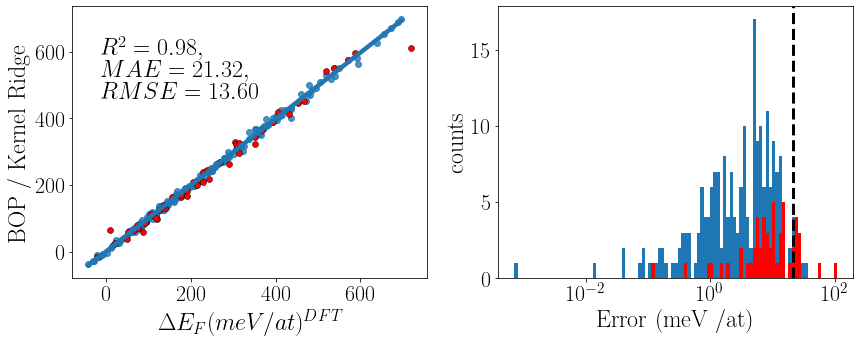

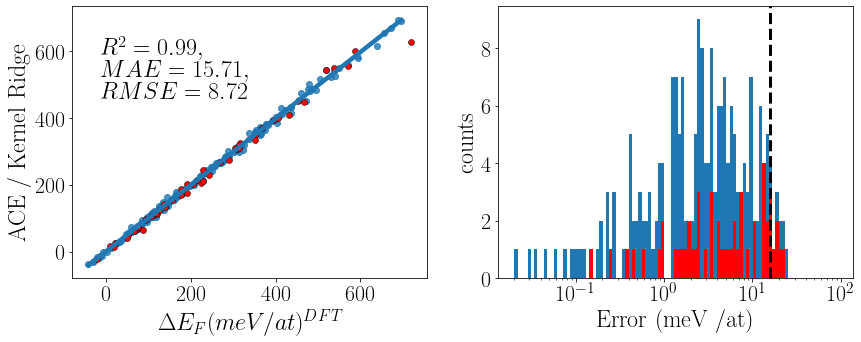

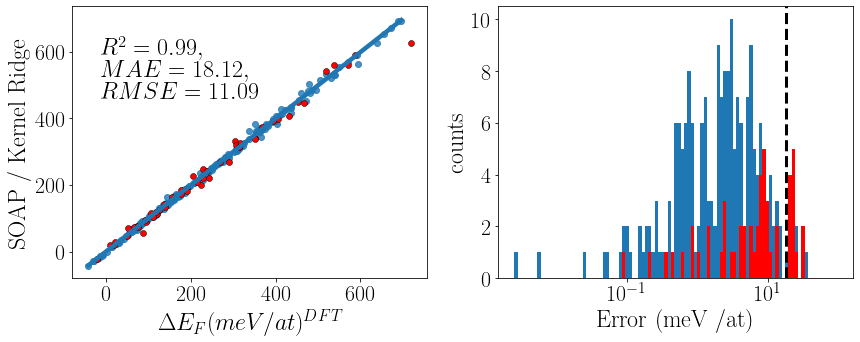

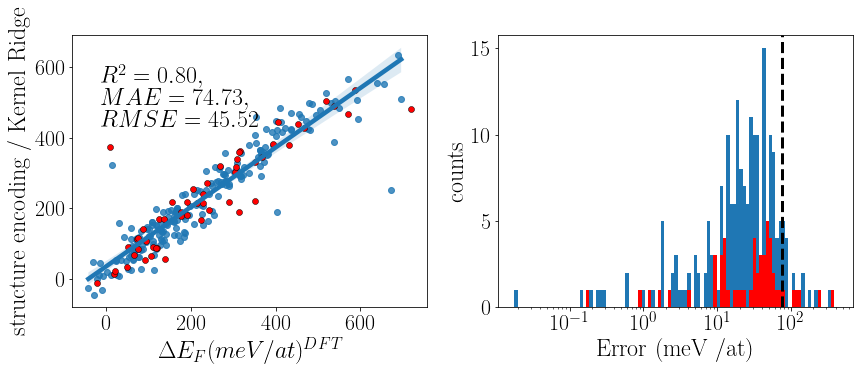

In [21]:
for featurenames, feature in DS.Features.items():
    filename = os.path.join(regpolots_loc, f'reg_error_plots_{dataset}_{modelname}_{featurenames}.pdf')
    prediction_name = f'{DS.target_name}_{ modelname }_{featurenames}'
    combi = (ModelName, featurenames)
    fig, ax = plt.subplots(1,2, figsize= [ plt.rcParams['figure.figsize'][0]*2, plt.rcParams['figure.figsize'][1] ]  )
    log_bins = np.logspace(np.log10(Err[combi].min()), np.log10(Err[combi].max()), 100 )
    sns.regplot(x=DS.BS[target_case][indexsplit['train']]*1000, y = predictionBS[prediction_name][indexsplit['train']]*1000, ax = ax[0])
    sns.scatterplot(x=DS.BS[target_case][indexsplit['test']]*1000, y = predictionBS[prediction_name][indexsplit['test']]*1000, ax = ax[0], facecolor='red', edgecolor='k')
    ax[0].set_ylabel(make_feature_labels(prediction_name)+' / '+ModelName)
    ax[0].set_xlabel('$\Delta E_{F} (meV/at) ^{DFT}$')
    ax[1].hist(Err[combi][indexsplit['train']], bins=log_bins)
    ax[1].hist(Err[combi][indexsplit['test']], bins=log_bins, color='red')
    ax[1].axvline(rmse[combi],ls='--',c='k')
    ax[1].annotate(r'$\\R^2 = {:.2f},\\MAE={:.2f},\\RMSE={:.2f}$'.format(r2[combi], rmse[combi], mae[combi]), (0.1, 0.8), xycoords='figure fraction' )
    ax[1].set_xscale('log')
    ax[1].set_ylabel ('counts')
    ax[1].set_xlabel('Error (meV /at)')
    fig.savefig(filename)
#    sns.histplot(x=E[combi], bins=log_bins, log_scale='x', ax = ax[1])

# convex hulls

In [22]:
predicted_targets = predictionBS.filter(regex=modelname).columns

In [23]:
PREDICT_CHULL = {}
phase_predictionBS = {}
for phase, predict_bs_phase in predictionBS.groupby(by='Phase'):
    if phase == 'R':
        continue
    phase_predictionBS[phase] = predict_bs_phase

In [24]:
for predicted_target in predicted_targets:
    PREDICT_CHULL[predicted_target] = {}
    for phase, predict_bs_phase in phase_predictionBS.items():
        PREDICT_CHULL[predicted_target].update(
            P.get_convex_hulls({phase: predict_bs_phase}, ['Fe', 'Mo'],getproperty=predicted_target)
        )

In [25]:
convexull_plots_loc = os.path.join(dataset, 'graphs', 'convex_hull_plots')

In [26]:
if not os.path.exists(convexull_plots_loc):
    os.makedirs(convexull_plots_loc)

In [27]:
predictionBS.columns

Index(['', 'V', 'E0', 'B', 'fit', 'xc', 'encut', 'deltak', 'ncrash', 'nelem',
       'B0', 'V0', 'atom_A', 'atom_B', 'num_atom_A', 'num_atom_B', 'num_atoms',
       'Fe_pv', 'Mo_sv', 'Mag', 'Phase', 'EF_fmbcc', 'EF_nmhcp', 'EF_nmfcc',
       'EF_nmhcp_KernelRidge_0.7dProjections 0.5OS BOP',
       'EF_nmhcp_KernelRidge_ACE', 'EF_nmhcp_KernelRidge_SOAP_specific_small',
       'EF_nmhcp_KernelRidge_dataset'],
      dtype='object')

In [28]:
predicted_targets=predictionBS.filter(regex=modelname).columns

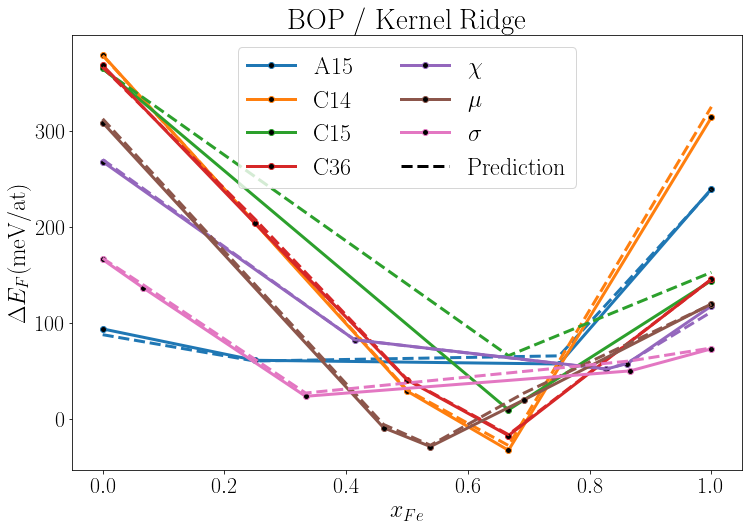

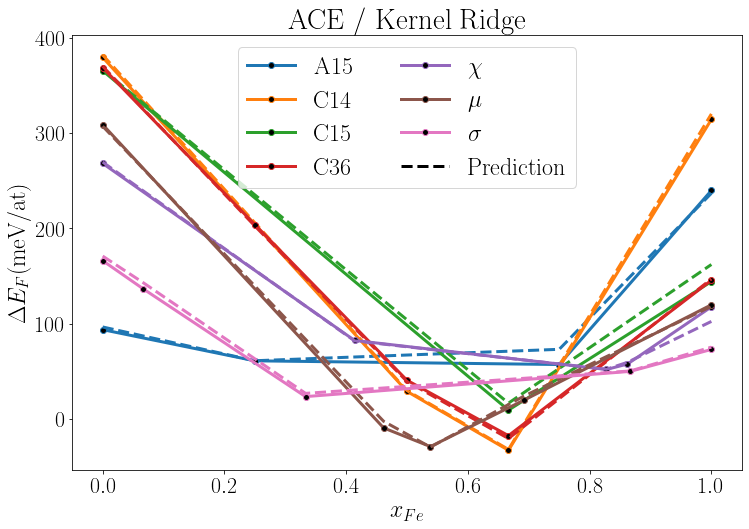

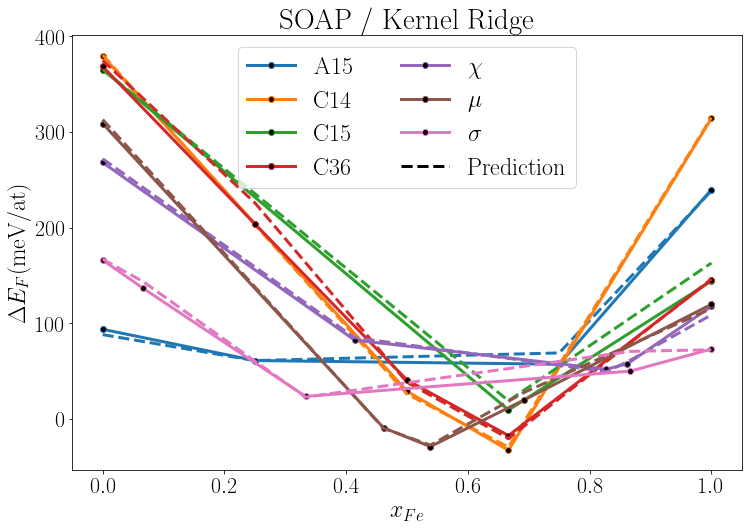

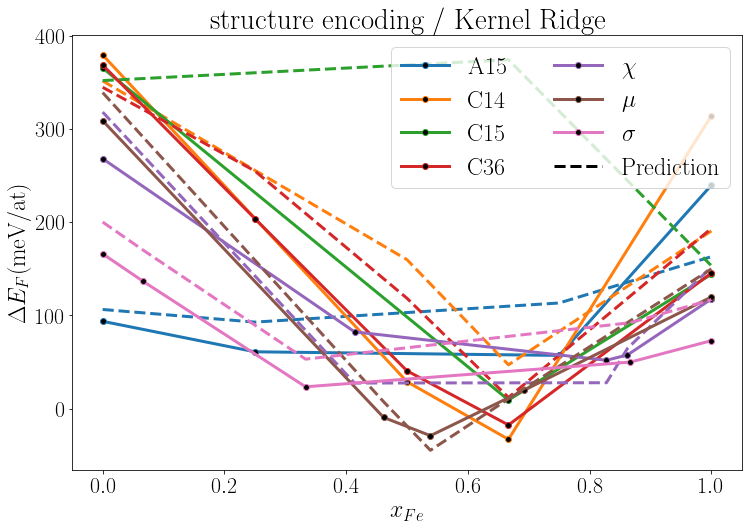

In [29]:
for predicted_target in predicted_targets:
    fig, ax = plt.subplots(figsize=(12,8))
    for phase, chull in CHULL.items():
        if phase == 'bcc':
            continue
        if phase == 'fcc':
            continue
        if phase == 'hcp':
            continue
        if phase == 'R':
            continue
        bs_phase = BS[BS.Phase == phase]
        prediction_phase_bs = phase_predictionBS[phase]
        vertices = np.unique( chull.simplices[chull.good])
        chull_prediction = PREDICT_CHULL[predicted_target][phase]
        prediction_vertices = np.unique(chull_prediction.vertices[chull_prediction.good])
        xy= bs_phase.iloc[vertices][['Fe_pv', target_case]].sort_values(by='Fe_pv')
        xy_prediction = prediction_phase_bs.iloc[vertices][['Fe_pv', predicted_target]].sort_values(by='Fe_pv')
        l=ax.plot(xy['Fe_pv'].values, xy[target_case].values*1000, '-o', markerfacecolor='k', label = make_phase_label(phase))
        ax.plot(xy_prediction['Fe_pv'].values, xy_prediction[predicted_target].values*1000, '--', color=l[0].get_color())
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([],[], linestyle='--', color='k'))
    labels.append('Prediction')
    ax.legend(handles, labels, ncol=2)
    ax.set_title(make_feature_labels(predicted_target)+' / '+ModelName)
    ax.set_xlabel(r'$x_{Fe}$')
    ax.set_ylabel(r'$\Delta E_F $(meV/at)')
    filename = os.path.join(convexull_plots_loc, f'{ dataset }_{predicted_target}_convex_hull_plot.pdf')
    fig.savefig(filename)

# Error on phases

In [30]:
phase_predictionBS.keys()

dict_keys(['A15', 'C14', 'C15', 'C36', 'chi', 'mu', 'sigma'])

In [31]:
phase_Err = {}

In [32]:
for (modelname, featurename), err in Err.items():
    phase_Err[(modelname, featurename)]= {} # err[phase_bs.index]
    for phase, phase_bs  in phase_predictionBS.items():
        phase_Err[(modelname, featurename)].update({phase : err[phase_bs.index]})

In [33]:
boxplot_loc = os.path.join(dataset, 'graphs', 'error_boxplots')
if not os.path.exists(boxplot_loc):
    os.makedirs(boxplot_loc)

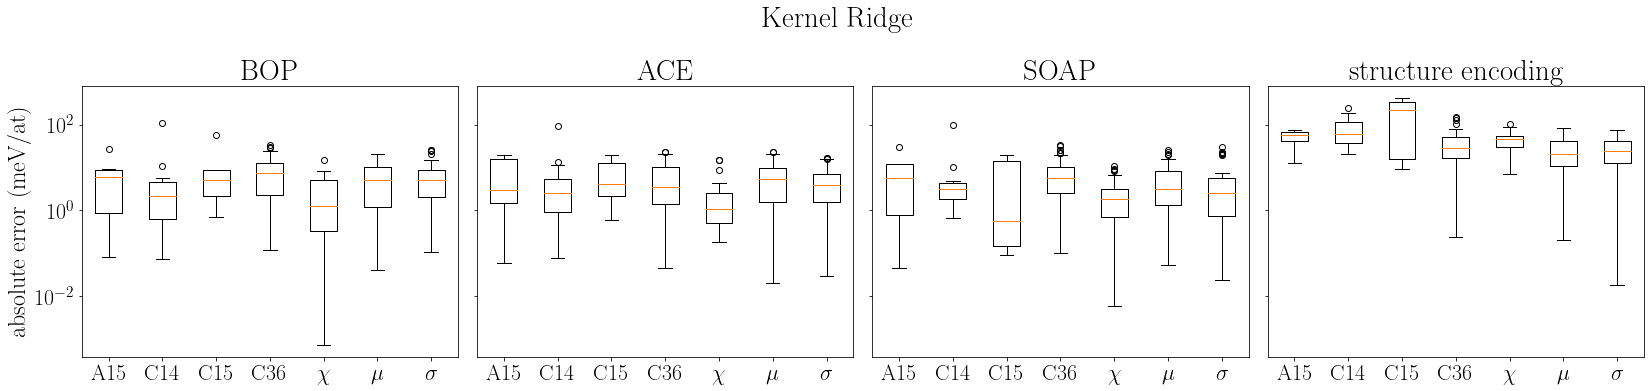

In [34]:
fig, axes = plt.subplots(1,len(Err), sharey=True, figsize=[plt.rcParams['figure.figsize'][0]*len(Err), plt.rcParams['figure.figsize'][1]])
plt.subplots_adjust(wspace=0.05)
for ax, ((modelname, featurename), phase_err) in zip(axes, phase_Err.items()):
    #break
#ax.boxplot(data=[ s.values for s in phase_Err.values() ], labels=phase_Err.keys())
    theplot = ax.boxplot(x=phase_err.values(), labels=[make_phase_label(phasename) for phasename in phase_err.keys()])#, whis=0.75)
    ax.set_yscale('log')
    ax.set_title(make_feature_labels(featurename))

ylabel = axes[0].set_ylabel('absolute error (meV/at)')
fig.suptitle(ModelName, y=1.1)
filename = os.path.join(boxplot_loc, f'{dataset}_{ModelName}_boxplot.pdf')
fig.savefig(filename)

In [35]:

for combi, err in Err.items():
    err.name = 'Absolute Error'
    Err[combi] = pd.concat([err, DS.StructureNames, DS.BS.Mag], axis = 1).dropna()
    Err[combi] = Err[combi][~Err[combi].index.str.contains('R')]

In [73]:
colors = sns.color_palette('bright', 8)

In [50]:
sns.color_palette('rocket', 8)

[(0.16342174, 0.0851396, 0.21088893),
 (0.33067031, 0.11701189, 0.30632563),
 (0.51728314, 0.1179558, 0.35453252),
 (0.70457834, 0.0882129, 0.34473046),
 (0.86641628, 0.17387796, 0.27070818),
 (0.94291042, 0.37549479, 0.26369821),
 (0.96173392, 0.57988594, 0.41844491),
 (0.96656022, 0.75658231, 0.62527295)]

In [52]:
sns.color_palette('husl', 8)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8087954113106306, 0.5634700050056693, 0.19502642696727285),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.19783576093349015, 0.6955516966063037, 0.3995301037444499),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.22335772267769388, 0.6565792317435265, 0.8171355503265633),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 (0.9603888539940703, 0.3814317878772117, 0.8683117650835491)]

In [56]:
sns.color_palette('Set1', 8)

In [75]:
colors

[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215),
 (0.6235294117647059, 0.2823529411764706, 0.0),
 (0.9450980392156862, 0.2980392156862745, 0.7568627450980392),
 (0.6392156862745098, 0.6392156862745098, 0.6392156862745098)]

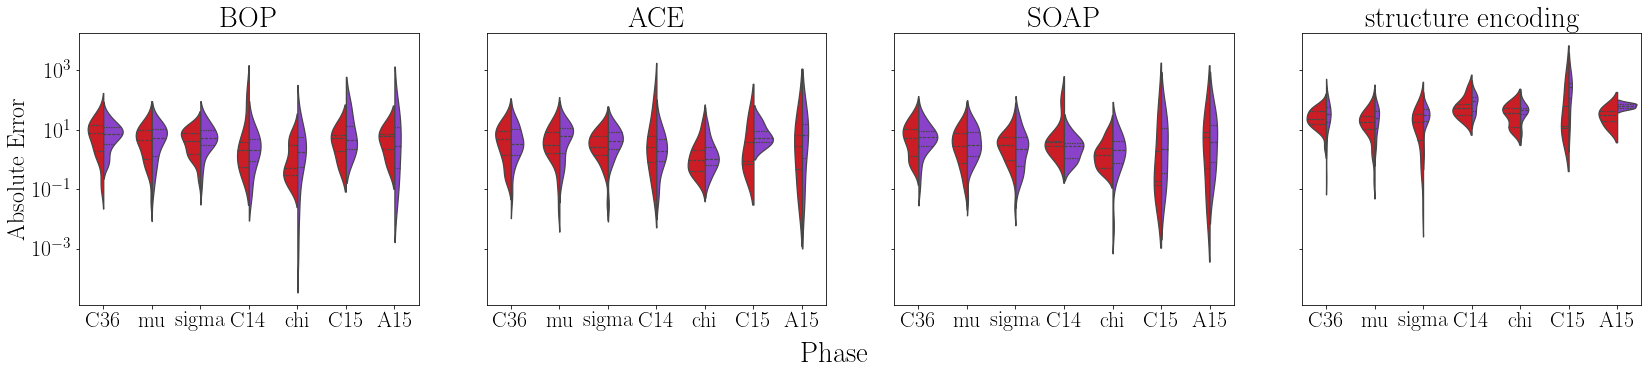

In [77]:
fig, axes = plt.subplots(1,len(Err), sharey=True, figsize=[plt.rcParams['figure.figsize'][0]*len(Err), plt.rcParams['figure.figsize'][1]])
for ((modelname, featurename), err), ax in zip(Err.items(), axes):
    ax.set_title(make_feature_labels(featurename) )
    sns.violinplot(
        Err[(modelname, featurename)], 
        ax=ax,
        x='Phase',
        y='Absolute Error', 
        hue='Mag', 
        split=True, 
        log_scale=True, 
        inner='quart', 
        legend=False,
        palette = [colors[3], colors[4]]
        ).set(xlabel=None)
fig.supxlabel('Phase', y=-0.05)
fig.savefig(f'Fe-Mo/graphs/error_boxplots/Fe-Mo_{modelname}_violinplot.pdf')